In [ ]:
"""
Here I start learning machine learning. Thou couldst learn.
"""

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model


In [7]:

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/lifesat/oecd_bli_2015.csv"
oecd_bli = pd.read_csv(url, thousands=',')
gdp_url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/lifesat/gdp_per_capita.csv"
gdp_per_capita = pd.read_csv(gdp_url, thousands=',', delimiter='\t', encoding='latin2', na_values="NAN&&NULLL")

In [21]:
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    if "Country" in gdp_per_capita.columns:
        gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                                  left_index=True, right_index=True)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    return full_country_stats

In [42]:
print(oecd_bli)
print(gdp_per_capita)

     LOCATION         Country INDICATOR  \
0         AUS       Australia   HO_BASE   
1         AUT         Austria   HO_BASE   
2         BEL         Belgium   HO_BASE   
3         CAN          Canada   HO_BASE   
4         CZE  Czech Republic   HO_BASE   
...       ...             ...       ...   
3287      EST         Estonia   WL_TNOW   
3288      ISR          Israel   WL_TNOW   
3289      RUS          Russia   WL_TNOW   
3290      SVN        Slovenia   WL_TNOW   
3291     OECD    OECD - Total   WL_TNOW   

                                      Indicator MEASURE Measure INEQUALITY  \
0            Dwellings without basic facilities       L   Value        TOT   
1            Dwellings without basic facilities       L   Value        TOT   
2            Dwellings without basic facilities       L   Value        TOT   
3            Dwellings without basic facilities       L   Value        TOT   
4            Dwellings without basic facilities       L   Value        TOT   
...            

In [22]:
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

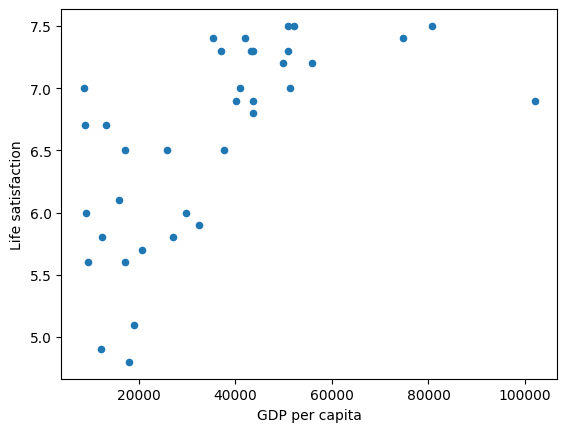

In [24]:
country_stats.plot(kind="scatter",x="GDP per capita", y = "Life satisfaction")
plt.show()

In [28]:
model = sklearn.linear_model.LinearRegression() # just some cool STA
model.fit(X, y)

X_new = [[22587]]
print(model.predict(X_new))

[[6.28653637]]


In [41]:
import sklearn.neighbors
model = sklearn.neighbors.KNeighborsRegressor(n_neighbors=1)
model.fit(X, y)
print(model.predict(X_new))


[[5.7]]


# PART 2